# 3-Stage UWB NLOS Correction Pipeline — Inference
## Exploiting Single-Bounce Dynamics for Indoor Positioning

**Full inference pipeline** chaining all 3 stages:

```
Raw CIR + FP_AMPL1/2/3
        │
  [ Preprocessing ]
        │
  [ Frozen DualCircuit_PI_HLNN encoder ]
        │
  64-dim LNN embedding
        │
  ┌─────┴─────┐
  │            │
Stage 1      Stage 2          Stage 3
Classifier   RF Classifier    RF Regressor
(LOS/NLOS)   (Correctable?)   (Ranging Error)
  │            │                │
  └─────┬──────┘                │
        │                       │
   NLOS + Correctable ──────> d_corrected = d_hw - predicted_error
   NLOS + Challenging ──────> flag as unreliable (use raw distance)
   LOS ─────────────────────> use raw distance (no correction needed)
```

**Artifacts required**:
- `stage1_pi_hlnn_fp_best.pt` — Frozen DualCircuit_PI_HLNN encoder + classifier
- `stage2_bounce_rf.joblib` — RF Classifier (correctable vs challenging)
- `stage3_nlos_bias_rf.joblib` — RF Regressor (ranging error prediction)

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import joblib
import re

# ==========================================
# CONFIGURATION
# ==========================================
CONFIG = {
    # CIR preprocessing (same as training)
    "search_start": 740,
    "search_end": 810,
    "pre_crop": 10,
    "post_crop": 50,
    "total_len": 60,
    # Stage 1 model
    "hidden_size": 32,
    "input_size": 1,
    "dropout": 0.2,
    "ode_unfolds": 6,
    # Stage 1 threshold
    "nlos_threshold": 0.5,
}

EMBEDDING_DIM = CONFIG["hidden_size"] * 2  # 64

print("3-Stage UWB NLOS Correction Pipeline — Inference")
print(f"  Stage 1: DualCircuit_PI_HLNN classifier (NLOS threshold={CONFIG['nlos_threshold']})")
print(f"  Stage 2: RF Classifier (correctable vs challenging)")
print(f"  Stage 3: RF Regressor (ranging error → d_corrected)")
print(f"  Shared encoder: {EMBEDDING_DIM}-dim LNN embeddings")

3-Stage UWB NLOS Correction Pipeline — Inference
  Stage 1: DualCircuit_PI_HLNN classifier (NLOS threshold=0.5)
  Stage 2: RF Classifier (correctable vs challenging)
  Stage 3: RF Regressor (ranging error → d_corrected)
  Shared encoder: 64-dim LNN embeddings


---
## Section 1: Model Definition + Load All Artifacts

Load all 3 stage models:
1. **Stage 1**: `DualCircuit_PI_HLNN` — provides both LOS/NLOS classification AND 64-dim embeddings for Stages 2/3
2. **Stage 2**: `RandomForestClassifier` — predicts correctable vs challenging from embeddings
3. **Stage 3**: `RandomForestRegressor` — predicts ranging error from embeddings

In [40]:
# ==========================================
# MODEL DEFINITION (must match Stage 1 training exactly)
# ==========================================
class PILiquidCell(nn.Module):
    """Conductance-based LTC cell (Hasani et al. 2020)."""
    def __init__(self, input_size, hidden_size, ode_unfolds=6):
        super().__init__()
        self.hidden_size = hidden_size
        self.input_size = input_size
        self.ode_unfolds = ode_unfolds

        self.gleak = nn.Parameter(torch.empty(hidden_size).uniform_(0.001, 1.0))
        self.vleak = nn.Parameter(torch.empty(hidden_size).uniform_(-0.2, 0.2))
        self.cm    = nn.Parameter(torch.empty(hidden_size).uniform_(0.4, 0.6))

        self.w     = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(0.001, 1.0))
        self.erev  = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(-0.2, 0.2))
        self.mu    = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(0.3, 0.8))
        self.sigma = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(3, 8))

        self.sensory_w     = nn.Parameter(torch.empty(input_size, hidden_size).uniform_(0.001, 1.0))
        self.sensory_mu    = nn.Parameter(torch.empty(input_size, hidden_size).uniform_(0.3, 0.8))
        self.sensory_sigma = nn.Parameter(torch.empty(input_size, hidden_size).uniform_(3, 8))

    def forward(self, x_t, h_prev, dt=1.0):
        gleak     = F.softplus(self.gleak)
        cm        = F.softplus(self.cm)
        w         = F.softplus(self.w)
        sensory_w = F.softplus(self.sensory_w)

        sensory_gate    = torch.sigmoid(self.sensory_sigma * (x_t.unsqueeze(-1) - self.sensory_mu))
        sensory_current = (sensory_w * sensory_gate * x_t.unsqueeze(-1)).sum(dim=1)

        cm_t = cm / (dt / self.ode_unfolds)
        v    = h_prev

        for _ in range(self.ode_unfolds):
            recurrent_gate = torch.sigmoid(self.sigma.unsqueeze(0) * (v.unsqueeze(2) - self.mu.unsqueeze(0)))
            w_gate = w.unsqueeze(0) * recurrent_gate
            w_num  = (w_gate * self.erev.unsqueeze(0)).sum(dim=1)
            w_den  = w_gate.sum(dim=1)
            numerator   = cm_t * v + gleak * self.vleak + w_num + sensory_current
            denominator = cm_t + gleak + w_den + 1e-8
            v = numerator / denominator
            v = torch.clamp(v, -1.0, 1.0)

        tau = cm / (gleak + w_den + 1e-8)
        return v, tau


class DualCircuit_PI_HLNN(nn.Module):
    """Dual-circuit PI-HLNN with cross-circuit communication + FP_AMPL conditioning."""
    def __init__(self, input_size=1, hidden_size=32, dropout=0.4, ode_unfolds=6):
        super().__init__()
        self.hidden_size = hidden_size

        self.cell_los  = PILiquidCell(input_size, hidden_size, ode_unfolds)
        self.cell_nlos = PILiquidCell(input_size, hidden_size, ode_unfolds)

        self.fp_to_los_init  = nn.Linear(3, hidden_size)
        self.fp_to_nlos_init = nn.Linear(3, hidden_size)

        self.P_nlos2los = nn.Linear(hidden_size, hidden_size, bias=False)
        self.P_los2nlos = nn.Linear(hidden_size, hidden_size, bias=False)

        self.gate_los  = nn.Linear(hidden_size * 2, hidden_size)
        self.gate_nlos = nn.Linear(hidden_size * 2, hidden_size)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1),
            nn.Sigmoid()
        )

    def _run_circuits(self, x_seq, fp_features=None):
        batch_size, seq_len, _ = x_seq.size()

        if fp_features is not None:
            h_los  = 0.01 * torch.tanh(self.fp_to_los_init(fp_features))
            h_nlos = 0.01 * torch.tanh(self.fp_to_nlos_init(fp_features))
        else:
            h_los  = torch.zeros(batch_size, self.hidden_size, device=x_seq.device)
            h_nlos = torch.zeros(batch_size, self.hidden_size, device=x_seq.device)

        los_states, nlos_states = [], []
        for t in range(seq_len):
            x_t = x_seq[:, t, :]
            proj_nlos_to_los = self.P_nlos2los(h_nlos)
            proj_los_to_nlos = self.P_los2nlos(h_los)
            g_los  = torch.sigmoid(self.gate_los( torch.cat([h_los,  proj_nlos_to_los], dim=1)))
            g_nlos = torch.sigmoid(self.gate_nlos(torch.cat([h_nlos, proj_los_to_nlos], dim=1)))
            h_los_in  = h_los  + g_los  * proj_nlos_to_los
            h_nlos_in = h_nlos + g_nlos * proj_los_to_nlos
            h_los,  _ = self.cell_los( x_t, h_los_in)
            h_nlos, _ = self.cell_nlos(x_t, h_nlos_in)
            los_states.append(h_los.unsqueeze(1))
            nlos_states.append(h_nlos.unsqueeze(1))

        los_all  = torch.cat(los_states,  dim=1)
        nlos_all = torch.cat(nlos_states, dim=1)
        return los_all, nlos_all

    def _pool_and_fuse(self, los_all, nlos_all):
        h_los_avg  = los_all.mean(dim=1)
        h_nlos_avg = nlos_all.mean(dim=1)
        return torch.cat([h_los_avg, h_nlos_avg], dim=1)

    def forward(self, x_seq, fp_features=None):
        los_all, nlos_all = self._run_circuits(x_seq, fp_features=fp_features)
        h_fused = self._pool_and_fuse(los_all, nlos_all)
        pred = self.classifier(h_fused)
        return pred, h_fused  # return both prediction AND embedding


print(f"DualCircuit_PI_HLNN defined: {sum(p.numel() for p in DualCircuit_PI_HLNN().parameters()):,} params")

DualCircuit_PI_HLNN defined: 17,153 params


In [41]:
# ==========================================
# LOAD ALL 3 STAGE ARTIFACTS
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Stage 1: LNN encoder + classifier ──
stage1_model = DualCircuit_PI_HLNN(
    input_size=CONFIG['input_size'],
    hidden_size=CONFIG['hidden_size'],
    dropout=CONFIG['dropout'],
    ode_unfolds=CONFIG['ode_unfolds'],
).to(device)
stage1_model.load_state_dict(
    torch.load('stage1_pi_hlnn_fp_best.pt', map_location=device, weights_only=True)
)
stage1_model.eval()
for param in stage1_model.parameters():
    param.requires_grad = False
print(f"Stage 1: Loaded DualCircuit_PI_HLNN from stage1_pi_hlnn_fp_best.pt")
print(f"  Device: {device}, Params: {sum(p.numel() for p in stage1_model.parameters()):,} (frozen)")

# ── Stage 2: RF Classifier ──
stage2_rf = joblib.load('stage2_bounce_rf.joblib')
print(f"Stage 2: Loaded RF Classifier from stage2_bounce_rf.joblib")
print(f"  Trees: {stage2_rf.n_estimators}, Classes: {list(stage2_rf.classes_)}")

# ── Stage 3: RF Regressor ──
stage3_rf = joblib.load('stage3_nlos_bias_rf.joblib')
print(f"Stage 3: Loaded RF Regressor from stage3_nlos_bias_rf.joblib")
print(f"  Trees: {stage3_rf.n_estimators}")

print(f"\nAll 3 stages loaded successfully.")

Stage 1: Loaded DualCircuit_PI_HLNN from stage1_pi_hlnn_fp_best.pt
  Device: cuda, Params: 17,153 (frozen)
Stage 2: Loaded RF Classifier from stage2_bounce_rf.joblib
  Trees: 200, Classes: [np.int64(0), np.int64(1)]
Stage 3: Loaded RF Regressor from stage3_nlos_bias_rf.joblib
  Trees: 200

All 3 stages loaded successfully.


---
## Section 2: Preprocessing Helpers

Same preprocessing as training: ROI alignment → 60-sample window → min-max normalize

In [42]:
# ==========================================
# PREPROCESSING (same as training)
# ==========================================
def get_roi_alignment(sig, search_start=CONFIG["search_start"],
                      search_end=CONFIG["search_end"]):
    """Find leading edge by backtracking from peak."""
    region = sig[search_start:search_end]
    if len(region) == 0:
        return np.argmax(sig)

    peak_local = np.argmax(region)
    peak_idx = search_start + peak_local
    peak_val = sig[peak_idx]

    noise_section = sig[:search_start]
    if len(noise_section) > 10:
        noise_mean = np.mean(noise_section)
        noise_std = np.std(noise_section)
        threshold = max(noise_mean + 3 * noise_std, 0.05 * peak_val)
    else:
        threshold = 0.05 * peak_val

    leading_edge = peak_idx
    for i in range(peak_idx, max(search_start - 20, 0), -1):
        if sig[i] < threshold:
            leading_edge = i + 1
            break

    return leading_edge


def preprocess_cir(sig, leading_edge):
    """Convert RXPACC-normalized CIR + leading edge to 60-sample window."""
    PRE = CONFIG['pre_crop']
    TOTAL = CONFIG['total_len']
    start = max(0, leading_edge - PRE)
    end = start + TOTAL
    if end > len(sig):
        end = len(sig)
        start = max(0, end - TOTAL)
    crop = sig[start:end]
    if len(crop) < TOTAL:
        crop = np.pad(crop, (0, TOTAL - len(crop)), mode='constant')
    local_min, local_max = np.min(crop), np.max(crop)
    rng = local_max - local_min
    crop = (crop - local_min) / rng if rng > 0 else np.zeros(TOTAL)
    return crop


def prepare_sample(row, cir_cols):
    """Prepare a single sample: CIR normalization, leading edge, FP features."""
    sig = pd.to_numeric(row[cir_cols], errors='coerce').fillna(0).astype(float).values

    rxpacc_col = 'RXPACC' if 'RXPACC' in row.index else 'RX_PACC'
    rxpacc = float(row.get(rxpacc_col, 128.0))
    if rxpacc > 0:
        sig = sig / rxpacc

    f1 = float(row.get('FP_AMPL1', 0)) / max(rxpacc, 1) / 64.0
    f2 = float(row.get('FP_AMPL2', 0)) / max(rxpacc, 1) / 64.0
    f3 = float(row.get('FP_AMPL3', 0)) / max(rxpacc, 1) / 64.0

    le = get_roi_alignment(sig)
    crop = preprocess_cir(sig, le)

    return crop, np.array([f1, f2, f3], dtype=np.float32)


print("Preprocessing functions defined.")

Preprocessing functions defined.


---
## Section 3: Load Demo Dataset

Load the combined dataset to demonstrate the full pipeline. In a real deployment, you would feed individual CIR measurements instead.

In [43]:
# ==========================================
# LOAD DATASET FOR DEMO
# ==========================================
filepath = "../dataset/channels/combined_uwb_dataset.csv"
df = pd.read_csv(filepath)
print(f"Loaded {len(df)} samples from {filepath}")
print(f"  LOS: {int((df['Label'] == 0).sum())}, NLOS: {int((df['Label'] == 1).sum())}")

cir_cols = sorted(
    [c for c in df.columns if c.startswith('CIR')],
    key=lambda x: int(x.replace('CIR', ''))
)

# Preprocess all samples
print(f"\nPreprocessing {len(df)} samples...")
cir_sequences = []
fp_features = []

for idx, row in df.iterrows():
    crop, fp = prepare_sample(row, cir_cols)
    cir_sequences.append(crop)
    fp_features.append(fp)

cir_tensor = torch.tensor(
    np.array(cir_sequences).reshape(-1, CONFIG['total_len'], 1),
    dtype=torch.float32
).to(device)

fp_tensor = torch.tensor(
    np.array(fp_features),
    dtype=torch.float32
).to(device)

# Ground truth for evaluation
labels_gt = df['Label'].values                # 0=LOS, 1=NLOS
d_hardware = df['Distance'].values             # what DW1000 reports
d_direct = df['d_direct'].values               # true TX→RX distance

print(f"  CIR tensor: {cir_tensor.shape}")
print(f"  FP tensor:  {fp_tensor.shape}")
print(f"\nReady for pipeline inference.")

Loaded 3600 samples from ../dataset/channels/combined_uwb_dataset.csv
  LOS: 1800, NLOS: 1800

Preprocessing 3600 samples...
  CIR tensor: torch.Size([3600, 60, 1])
  FP tensor:  torch.Size([3600, 3])

Ready for pipeline inference.


---
## Section 4: Full Pipeline Inference

Run all 3 stages in sequence:

1. **Stage 1** (LNN): Classify LOS/NLOS + extract 64-dim embeddings (single forward pass)
2. **Stage 2** (RF Classifier): For NLOS samples → correctable or challenging?
3. **Stage 3** (RF Regressor): For correctable NLOS → predict ranging error → correct distance

Key: Stages 2 and 3 reuse the **same embedding** from Stage 1 — no redundant computation.

In [44]:
# ==========================================
# STAGE 1: LOS/NLOS Classification + Embedding Extraction
# ==========================================
print("Stage 1: LOS/NLOS Classification")
print("=" * 50)

all_nlos_probs = []
all_embeddings = []

BATCH_SIZE = 256
with torch.no_grad():
    for i in range(0, len(cir_tensor), BATCH_SIZE):
        batch_cir = cir_tensor[i:i+BATCH_SIZE]
        batch_fp  = fp_tensor[i:i+BATCH_SIZE]
        pred, embedding = stage1_model(batch_cir, fp_features=batch_fp)
        all_nlos_probs.append(pred.cpu().numpy().flatten())
        all_embeddings.append(embedding.cpu().numpy())

nlos_probs = np.concatenate(all_nlos_probs)        # (N,) NLOS probability
embeddings = np.vstack(all_embeddings)              # (N, 64) LNN embeddings

# Classify: NLOS if probability >= threshold
stage1_pred = (nlos_probs >= CONFIG['nlos_threshold']).astype(int)

n_los_pred  = int(np.sum(stage1_pred == 0))
n_nlos_pred = int(np.sum(stage1_pred == 1))

# Stage 1 accuracy (vs ground truth)
stage1_acc = (stage1_pred == labels_gt).mean()

print(f"  Predicted LOS:  {n_los_pred}")
print(f"  Predicted NLOS: {n_nlos_pred}")
print(f"  Accuracy: {100*stage1_acc:.2f}% (vs ground truth)")
print(f"  Embeddings: {embeddings.shape}")

Stage 1: LOS/NLOS Classification
  Predicted LOS:  1807
  Predicted NLOS: 1793
  Accuracy: 99.47% (vs ground truth)
  Embeddings: (3600, 64)


In [45]:
# ==========================================
# STAGE 2: Correctable vs Challenging (NLOS only)
# ==========================================
print("\nStage 2: Single-Bounce Identification (NLOS only)")
print("=" * 50)

nlos_mask = stage1_pred == 1
nlos_indices = np.where(nlos_mask)[0]
nlos_embeddings = embeddings[nlos_indices]

# RF Classifier: correctable (0) vs challenging (1)
stage2_pred = stage2_rf.predict(nlos_embeddings)
stage2_proba = stage2_rf.predict_proba(nlos_embeddings)

n_correctable = int(np.sum(stage2_pred == 0))
n_challenging = int(np.sum(stage2_pred == 1))

print(f"  NLOS samples: {len(nlos_indices)}")
print(f"  Correctable (single-bounce identified): {n_correctable}")
print(f"  Challenging (unreliable for correction): {n_challenging}")

# Indices of correctable samples (in original dataset)
correctable_mask_in_nlos = stage2_pred == 0
correctable_indices = nlos_indices[correctable_mask_in_nlos]  # indices in original df
correctable_embeddings = nlos_embeddings[correctable_mask_in_nlos]

print(f"  → {n_correctable} samples forwarded to Stage 3")


Stage 2: Single-Bounce Identification (NLOS only)
  NLOS samples: 1793
  Correctable (single-bounce identified): 528
  Challenging (unreliable for correction): 1265
  → 528 samples forwarded to Stage 3


In [46]:
# ==========================================
# STAGE 3: Ranging Error Prediction (Correctable only)
# ==========================================
print("\nStage 3: Ranging Error Correction (Correctable NLOS only)")
print("=" * 50)

if len(correctable_indices) > 0:
    # RF Regressor: predict ranging error from embeddings
    predicted_errors = stage3_rf.predict(correctable_embeddings)

    # Apply correction
    d_hw_correctable = d_hardware[correctable_indices]
    d_corrected = d_hw_correctable - predicted_errors

    print(f"  Samples corrected: {len(correctable_indices)}")
    print(f"  Predicted error — mean: {predicted_errors.mean():.3f}m, std: {predicted_errors.std():.3f}m")
    print(f"  d_hardware — mean: {d_hw_correctable.mean():.3f}m")
    print(f"  d_corrected — mean: {d_corrected.mean():.3f}m")
else:
    predicted_errors = np.array([])
    d_corrected = np.array([])
    print(f"  No correctable samples — Stage 3 skipped")


Stage 3: Ranging Error Correction (Correctable NLOS only)
  Samples corrected: 528
  Predicted error — mean: 3.415m, std: 1.566m
  d_hardware — mean: 11.399m
  d_corrected — mean: 7.984m


---
## Section 5: Pipeline Results

Assemble final corrected distances for all samples:
- **LOS**: use raw `d_hardware` (no correction needed)
- **NLOS + Correctable**: use `d_corrected = d_hardware - predicted_error`
- **NLOS + Challenging**: use raw `d_hardware` (correction unreliable)

In [47]:
# ==========================================
# ASSEMBLE FINAL DISTANCES
# ==========================================
d_final = d_hardware.copy()  # start with raw hardware distances
pipeline_status = np.full(len(df), 'LOS', dtype=object)

# Mark NLOS samples
pipeline_status[nlos_mask] = 'NLOS_challenging'

# Apply Stage 3 correction to correctable samples
if len(correctable_indices) > 0:
    d_final[correctable_indices] = d_corrected
    pipeline_status[correctable_indices] = 'NLOS_corrected'

# ── Summary table ──
print("Pipeline Output Summary")
print("=" * 60)
for status in ['LOS', 'NLOS_corrected', 'NLOS_challenging']:
    mask = pipeline_status == status
    n = int(mask.sum())
    if n == 0:
        continue
    raw_error = np.abs(d_hardware[mask] - d_direct[mask])
    final_error = np.abs(d_final[mask] - d_direct[mask])
    print(f"\n  {status} (n={n}):")
    print(f"    Raw MAE:       {raw_error.mean():.4f}m")
    print(f"    Final MAE:     {final_error.mean():.4f}m")
    if raw_error.mean() > 0:
        improvement = raw_error.mean() / max(final_error.mean(), 1e-6)
        if status == 'NLOS_corrected':
            print(f"    Improvement:   {improvement:.1f}x")

# ── Overall ──
overall_raw_mae = np.abs(d_hardware - d_direct).mean()
overall_final_mae = np.abs(d_final - d_direct).mean()
print(f"\n  {'─' * 50}")
print(f"  OVERALL (n={len(df)}):")
print(f"    Raw MAE:       {overall_raw_mae:.4f}m")
print(f"    Final MAE:     {overall_final_mae:.4f}m")
print(f"    Improvement:   {overall_raw_mae / max(overall_final_mae, 1e-6):.1f}x")

Pipeline Output Summary

  LOS (n=1807):
    Raw MAE:       0.1104m
    Final MAE:     0.1104m

  NLOS_corrected (n=528):
    Raw MAE:       3.3917m
    Final MAE:     0.3061m
    Improvement:   11.1x

  NLOS_challenging (n=1265):
    Raw MAE:       1.1320m
    Final MAE:     1.1320m

  ──────────────────────────────────────────────────
  OVERALL (n=3600):
    Raw MAE:       0.9507m
    Final MAE:     0.4981m
    Improvement:   1.9x


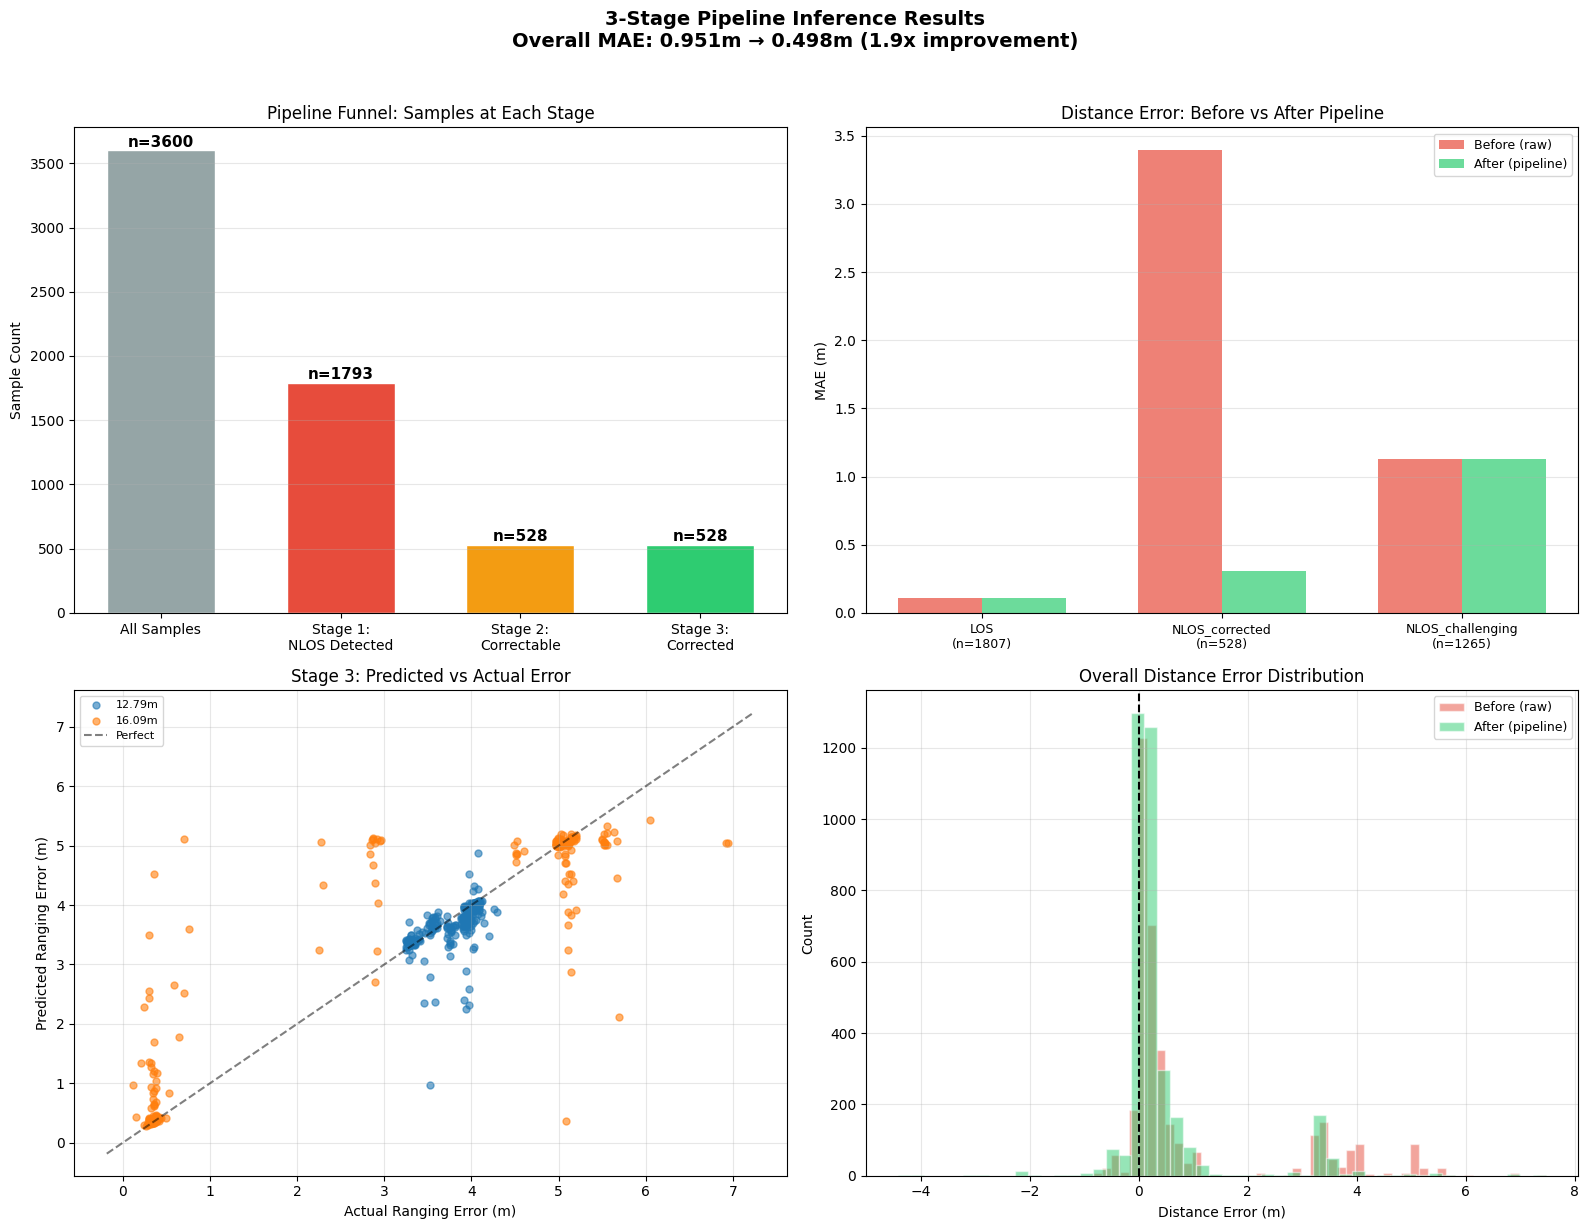

In [48]:
# ==========================================
# PIPELINE FLOW VISUALIZATION
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ─── 1. Pipeline funnel: sample counts at each stage ───
ax = axs[0, 0]
stages = ['All Samples', 'Stage 1:\nNLOS Detected', 'Stage 2:\nCorrectable', 'Stage 3:\nCorrected']
counts = [len(df), n_nlos_pred, n_correctable, n_correctable]
colors_bar = ['#95a5a6', '#e74c3c', '#f39c12', '#2ecc71']
bars = ax.bar(stages, counts, color=colors_bar, edgecolor='white', width=0.6)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'n={count}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Sample Count')
ax.set_title('Pipeline Funnel: Samples at Each Stage')
ax.grid(True, alpha=0.3, axis='y')

# ─── 2. Before vs After: per-status MAE ───
ax = axs[0, 1]
status_labels = []
raw_maes = []
final_maes = []
for status in ['LOS', 'NLOS_corrected', 'NLOS_challenging']:
    mask = pipeline_status == status
    n = int(mask.sum())
    if n == 0:
        continue
    status_labels.append(f"{status}\n(n={n})")
    raw_maes.append(np.abs(d_hardware[mask] - d_direct[mask]).mean())
    final_maes.append(np.abs(d_final[mask] - d_direct[mask]).mean())

x_pos = np.arange(len(status_labels))
w = 0.35
ax.bar(x_pos - w/2, raw_maes, w, color='#e74c3c', alpha=0.7, label='Before (raw)')
ax.bar(x_pos + w/2, final_maes, w, color='#2ecc71', alpha=0.7, label='After (pipeline)')
ax.set_xticks(x_pos)
ax.set_xticklabels(status_labels, fontsize=9)
ax.set_ylabel('MAE (m)')
ax.set_title('Distance Error: Before vs After Pipeline')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# ─── 3. Corrected NLOS: predicted vs actual error ───
ax = axs[1, 0]
if len(correctable_indices) > 0:
    actual_errors = d_hardware[correctable_indices] - d_direct[correctable_indices]
    
    # Color by scenario
    source_files = df['Source_File'].values
    groups_corr = []
    for idx in correctable_indices:
        match = re.search(r'([\d.]+)m_nlos', str(source_files[idx]))
        groups_corr.append(match.group(1) + 'm' if match else 'unknown')
    groups_corr = np.array(groups_corr)
    unique_groups = sorted(set(groups_corr))
    
    for g in unique_groups:
        g_mask = groups_corr == g
        ax.scatter(actual_errors[g_mask], predicted_errors[g_mask],
                   s=25, alpha=0.6, label=g)
    lims = [min(actual_errors.min(), predicted_errors.min()) - 0.3,
            max(actual_errors.max(), predicted_errors.max()) + 0.3]
    ax.plot(lims, lims, 'k--', lw=1.5, alpha=0.5, label='Perfect')
    ax.set_xlabel('Actual Ranging Error (m)')
    ax.set_ylabel('Predicted Ranging Error (m)')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'No correctable samples', ha='center', va='center')
ax.set_title('Stage 3: Predicted vs Actual Error')
ax.grid(True, alpha=0.3)

# ─── 4. Histogram: final distance error (all samples) ───
ax = axs[1, 1]
raw_all_error = d_hardware - d_direct
final_all_error = d_final - d_direct
ax.hist(raw_all_error, bins=50, color='#e74c3c', alpha=0.5, label='Before (raw)', edgecolor='white')
ax.hist(final_all_error, bins=50, color='#2ecc71', alpha=0.5, label='After (pipeline)', edgecolor='white')
ax.axvline(0, color='black', ls='--', lw=1.5)
ax.set_xlabel('Distance Error (m)')
ax.set_ylabel('Count')
ax.set_title('Overall Distance Error Distribution')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle(f'3-Stage Pipeline Inference Results\n'
             f'Overall MAE: {overall_raw_mae:.3f}m → {overall_final_mae:.3f}m '
             f'({overall_raw_mae / max(overall_final_mae, 1e-6):.1f}x improvement)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Section 6: Stage 1 Diagnostics — LOS/NLOS Classification

Evaluate Stage 1 performance on the full dataset:
- **Confusion matrix**: LOS vs NLOS classification accuracy
- **NLOS probability distribution**: Separation between LOS and NLOS samples
- **ROC curve**: Discrimination quality across all thresholds

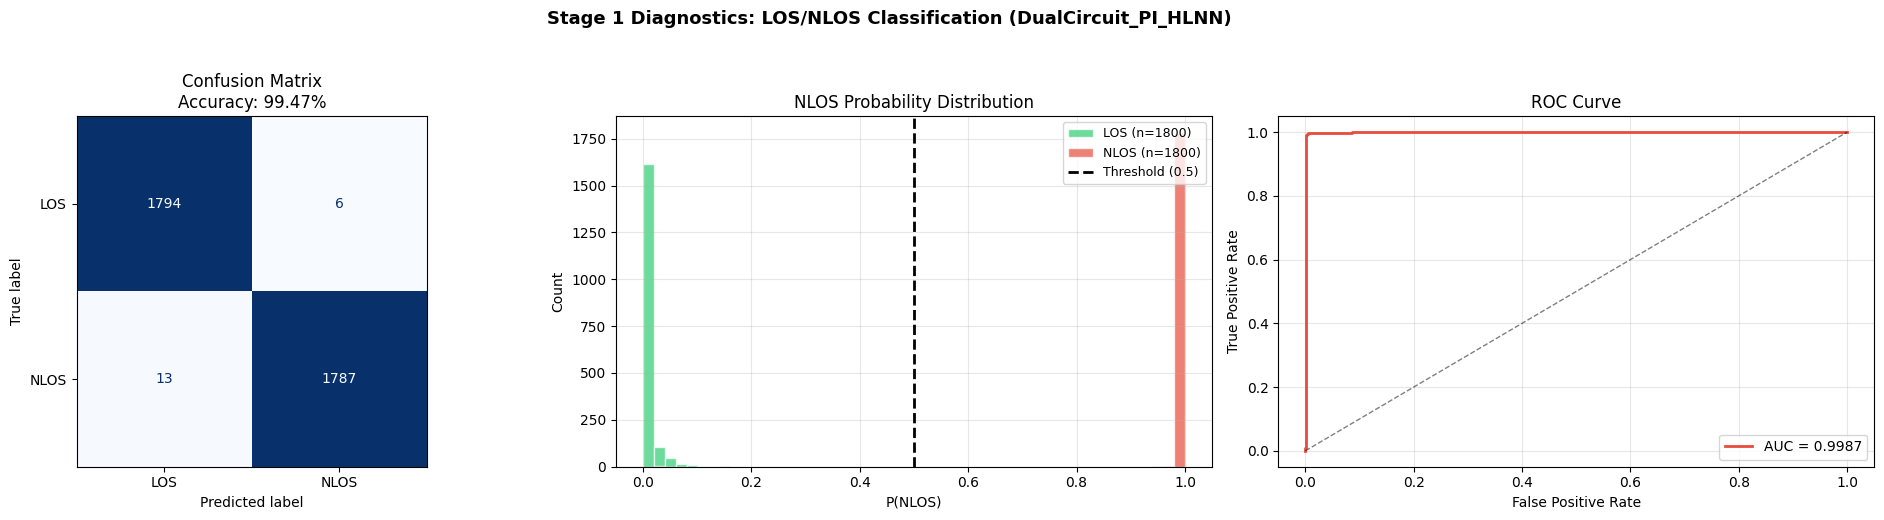

Stage 1 — Classification Report:
  Accuracy: 99.47%, AUC: 0.9987
  True LOS  → predicted LOS:  1794/1800 (99.7%)
  True NLOS → predicted NLOS: 1787/1800 (99.3%)


In [49]:
# ==========================================
# STAGE 1 DIAGNOSTICS
# ==========================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

fig, axs = plt.subplots(1, 3, figsize=(20, 5))
plt.subplots_adjust(wspace=0.35)

# ─── 1. Confusion Matrix ───
ax = axs[0]
cm1 = confusion_matrix(labels_gt, stage1_pred)
disp = ConfusionMatrixDisplay(cm1, display_labels=['LOS', 'NLOS'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"Confusion Matrix\nAccuracy: {100*stage1_acc:.2f}%")

# ─── 2. NLOS Probability Distribution ───
ax = axs[1]
los_mask_gt = labels_gt == 0
nlos_mask_gt = labels_gt == 1
ax.hist(nlos_probs[los_mask_gt], bins=50, color='#2ecc71', alpha=0.7,
        label=f'LOS (n={int(los_mask_gt.sum())})', edgecolor='white')
ax.hist(nlos_probs[nlos_mask_gt], bins=50, color='#e74c3c', alpha=0.7,
        label=f'NLOS (n={int(nlos_mask_gt.sum())})', edgecolor='white')
ax.axvline(CONFIG['nlos_threshold'], color='black', ls='--', lw=2,
           label=f'Threshold ({CONFIG["nlos_threshold"]})')
ax.set_xlabel('P(NLOS)')
ax.set_ylabel('Count')
ax.set_title('NLOS Probability Distribution')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ─── 3. ROC Curve ───
ax = axs[2]
fpr, tpr, _ = roc_curve(labels_gt, nlos_probs)
roc_auc = auc(fpr, tpr)
ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.suptitle('Stage 1 Diagnostics: LOS/NLOS Classification (DualCircuit_PI_HLNN)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print(f"Stage 1 — Classification Report:")
print(f"  Accuracy: {100*stage1_acc:.2f}%, AUC: {roc_auc:.4f}")
print(f"  True LOS  → predicted LOS:  {cm1[0,0]}/{cm1[0].sum()} ({100*cm1[0,0]/cm1[0].sum():.1f}%)")
print(f"  True NLOS → predicted NLOS: {cm1[1,1]}/{cm1[1].sum()} ({100*cm1[1,1]/cm1[1].sum():.1f}%)")

---
## Section 7: Stage 2 Diagnostics — Signal Quality Classification

Compute ground truth mixture labels (bounce dominance + peak count) for NLOS samples predicted by Stage 1, then compare against Stage 2 RF predictions:
- **Confusion matrix**: Correctable vs Challenging (predicted vs ground truth)
- **Confidence distribution**: RF probability for correctable class
- **ROC curve**: Stage 2 discrimination quality

Computing ground truth mixture labels for Stage 2 evaluation...
  True NLOS samples in Stage 2 input: 1787
  GT Correctable: 479, GT Challenging: 1308


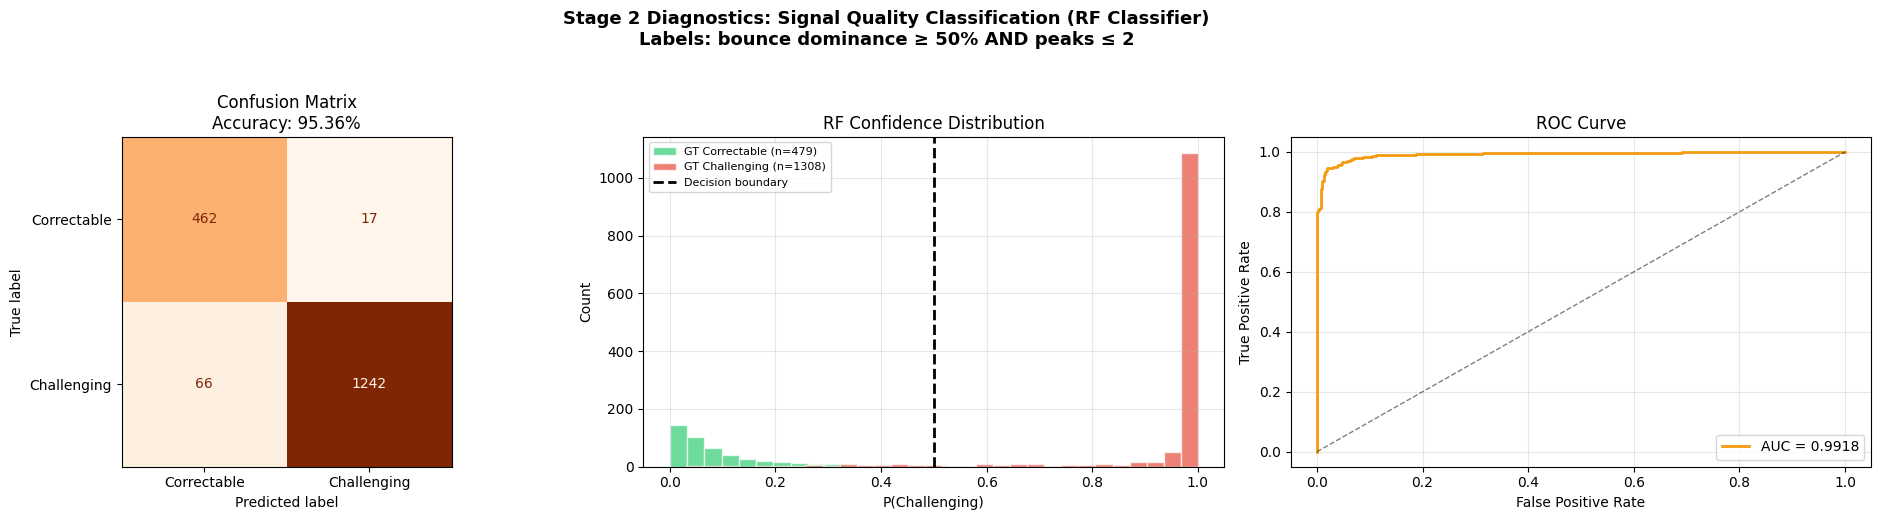


Stage 2 — Classification Report:
  Accuracy: 95.36%, AUC: 0.9918
  TP (correct correctable): 462, FN (missed correctable): 17
  FP (false correctable):   66, TN (correct challenging): 1242


In [50]:
# ==========================================
# STAGE 2 DIAGNOSTICS — Compute ground truth + compare
# ==========================================
from scipy.signal import find_peaks

# Stage 2 labeling config (must match stage2 training)
S2_PEAK_PROMINENCE = 0.20
S2_PEAK_MIN_DISTANCE = 5
S2_MAX_PEAKS = 2
S2_BOUNCE_WINDOW = 3
S2_DOM_THRESHOLD = 0.50

def count_peaks_roi(sig, leading_edge):
    """Count prominent peaks in CIR ROI (120 samples from leading edge)."""
    roi_start = max(0, leading_edge - 5)
    roi_end = min(len(sig), leading_edge + 120)
    roi = sig[roi_start:roi_end]
    if len(roi) == 0 or np.max(roi) == 0:
        return 0
    roi_norm = roi / np.max(roi)
    peaks, _ = find_peaks(roi_norm, prominence=S2_PEAK_PROMINENCE, distance=S2_PEAK_MIN_DISTANCE)
    return len(peaks)

def compute_bounce_dominance(sig, leading_edge, bounce_path_idx, window=S2_BOUNCE_WINDOW):
    """Fraction of ROI energy at known bounce position."""
    roi_start = max(0, leading_edge - 5)
    roi_end = min(len(sig), leading_edge + 120)
    roi_energy = np.sum(sig[roi_start:roi_end] ** 2)
    if roi_energy < 1e-10:
        return 0.0
    bounce_idx = int(round(bounce_path_idx))
    b_start = max(roi_start, bounce_idx - window)
    b_end = min(roi_end, bounce_idx + window + 1)
    if b_start >= b_end:
        return 0.0
    return np.sum(sig[b_start:b_end] ** 2) / roi_energy

# Compute ground truth labels for NLOS samples that Stage 1 predicted as NLOS
# Need raw RXPACC-normalized signals for these samples
print("Computing ground truth mixture labels for Stage 2 evaluation...")
gt_quality = np.full(len(nlos_indices), -1, dtype=int)

for i, orig_idx in enumerate(nlos_indices):
    row = df.iloc[orig_idx]
    sig = pd.to_numeric(row[cir_cols], errors='coerce').fillna(0).astype(float).values
    rxpacc_col = 'RXPACC' if 'RXPACC' in row.index else 'RX_PACC'
    rxpacc = float(row.get(rxpacc_col, 128.0))
    if rxpacc > 0:
        sig = sig / rxpacc

    le = get_roi_alignment(sig)
    n_peaks = count_peaks_roi(sig, le)
    bpi = float(row.get('bounce_path_idx', np.nan))

    if np.isnan(bpi):
        # LOS sample misclassified as NLOS — no bounce_path_idx available
        gt_quality[i] = 1  # challenging (no bounce to exploit)
    else:
        bd = compute_bounce_dominance(sig, le, bpi)
        is_correctable = (bd >= S2_DOM_THRESHOLD) and (n_peaks <= S2_MAX_PEAKS)
        gt_quality[i] = 0 if is_correctable else 1

# Only evaluate on true NLOS samples (where ground truth is meaningful)
true_nlos_in_pred = np.array([labels_gt[idx] == 1 for idx in nlos_indices])
eval_mask = true_nlos_in_pred  # only evaluate where we have true NLOS ground truth

gt_eval = gt_quality[eval_mask]
pred_eval = stage2_pred[eval_mask]
proba_eval = stage2_proba[eval_mask]

stage2_acc = (gt_eval == pred_eval).mean()
n_gt_corr = int(np.sum(gt_eval == 0))
n_gt_chal = int(np.sum(gt_eval == 1))

print(f"  True NLOS samples in Stage 2 input: {int(eval_mask.sum())}")
print(f"  GT Correctable: {n_gt_corr}, GT Challenging: {n_gt_chal}")

fig, axs = plt.subplots(1, 3, figsize=(20, 5))
plt.subplots_adjust(wspace=0.35)

# ─── 1. Confusion Matrix ───
ax = axs[0]
cm2 = confusion_matrix(gt_eval, pred_eval)
disp = ConfusionMatrixDisplay(cm2, display_labels=['Correctable', 'Challenging'])
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title(f"Confusion Matrix\nAccuracy: {100*stage2_acc:.2f}%")

# ─── 2. Confidence Distribution ───
ax = axs[1]
# P(challenging) = column 1 of proba
p_challenging = proba_eval[:, 1] if proba_eval.shape[1] > 1 else proba_eval[:, 0]
ax.hist(p_challenging[gt_eval == 0], bins=30, color='#2ecc71', alpha=0.7,
        label=f'GT Correctable (n={n_gt_corr})', edgecolor='white')
ax.hist(p_challenging[gt_eval == 1], bins=30, color='#e74c3c', alpha=0.7,
        label=f'GT Challenging (n={n_gt_chal})', edgecolor='white')
ax.axvline(0.5, color='black', ls='--', lw=2, label='Decision boundary')
ax.set_xlabel('P(Challenging)')
ax.set_ylabel('Count')
ax.set_title('RF Confidence Distribution')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ─── 3. ROC Curve ───
ax = axs[2]
fpr2, tpr2, _ = roc_curve(gt_eval, p_challenging)
roc_auc2 = auc(fpr2, tpr2)
ax.plot(fpr2, tpr2, color='#f39c12', lw=2, label=f'AUC = {roc_auc2:.4f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.suptitle(f'Stage 2 Diagnostics: Signal Quality Classification (RF Classifier)\n'
             f'Labels: bounce dominance ≥ {S2_DOM_THRESHOLD:.0%} AND peaks ≤ {S2_MAX_PEAKS}',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print(f"\nStage 2 — Classification Report:")
print(f"  Accuracy: {100*stage2_acc:.2f}%, AUC: {roc_auc2:.4f}")
print(f"  TP (correct correctable): {cm2[0,0]}, FN (missed correctable): {cm2[0,1]}")
print(f"  FP (false correctable):   {cm2[1,0]}, TN (correct challenging): {cm2[1,1]}")

---
## Section 8: Stage 3 Diagnostics — Ranging Error Correction

Evaluate Stage 3 correction quality on correctable NLOS samples:
- **Residual distribution**: Prediction residuals (predicted - actual error)
- **Per-scenario correction**: Before vs after MAE breakdown by NLOS scenario
- **Corrected distance scatter**: d_corrected vs d_direct (ground truth)

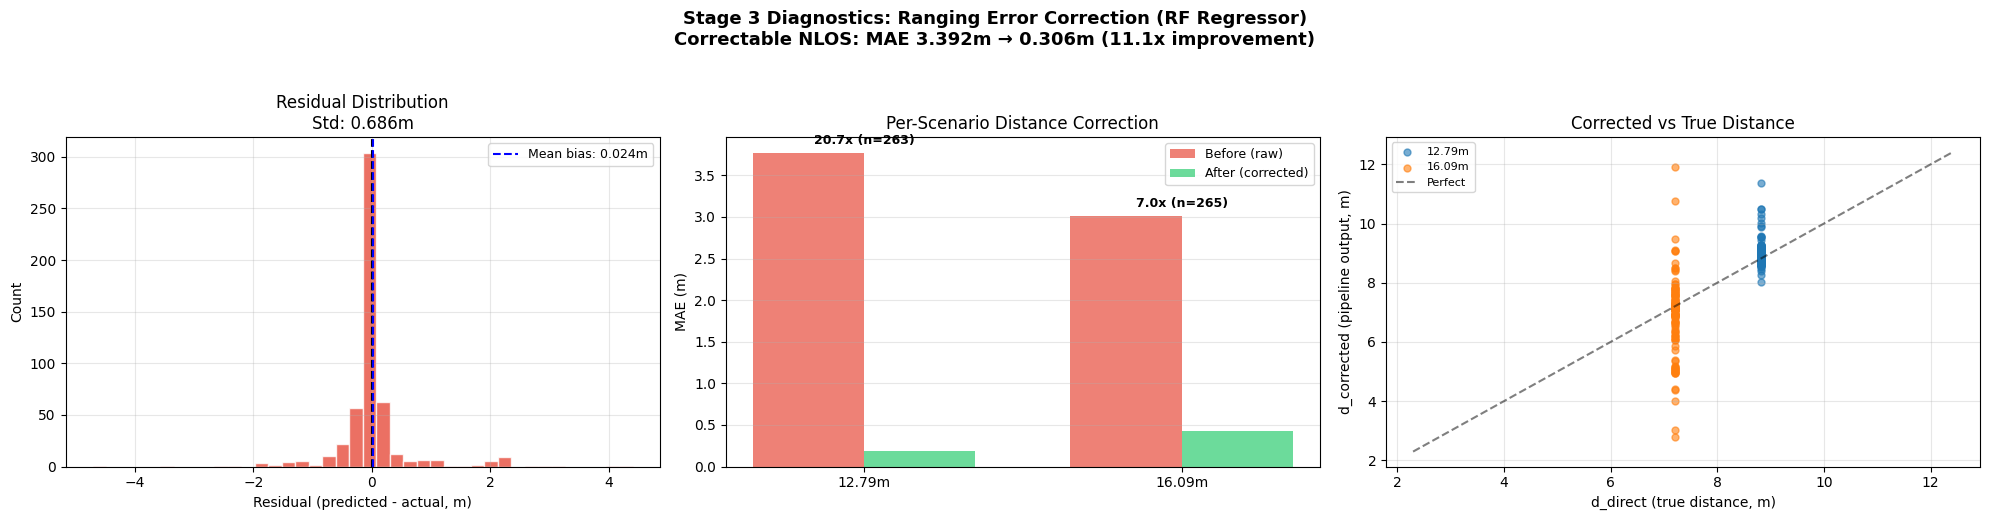

Stage 3 — Correction Report:
  Samples: 528
  Raw MAE:       3.3917m
  Corrected MAE: 0.3061m
  Improvement:   11.1x
  Residual mean: 0.0236m, std: 0.6858m


In [51]:
# ==========================================
# STAGE 3 DIAGNOSTICS
# ==========================================
if len(correctable_indices) > 0:
    actual_errors_s3 = d_hardware[correctable_indices] - d_direct[correctable_indices]
    residuals_s3 = predicted_errors - actual_errors_s3
    corrected_distances_s3 = d_hardware[correctable_indices] - predicted_errors
    corrected_errors_s3 = corrected_distances_s3 - d_direct[correctable_indices]

    # Scenario groups for correctable samples
    source_files = df['Source_File'].values
    groups_s3 = []
    for idx in correctable_indices:
        match = re.search(r'([\d.]+)m_nlos', str(source_files[idx]))
        groups_s3.append(match.group(1) + 'm' if match else 'unknown')
    groups_s3 = np.array(groups_s3)
    unique_groups_s3 = sorted(set(groups_s3))

    fig, axs = plt.subplots(1, 3, figsize=(20, 5))
    plt.subplots_adjust(wspace=0.35)

    # ─── 1. Residual Distribution ───
    ax = axs[0]
    ax.hist(residuals_s3, bins=40, color='#e74c3c', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='black', ls='--', lw=1.5)
    ax.axvline(residuals_s3.mean(), color='blue', ls='--', lw=1.5,
               label=f'Mean bias: {residuals_s3.mean():.3f}m')
    ax.set_xlabel('Residual (predicted - actual, m)')
    ax.set_ylabel('Count')
    ax.set_title(f'Residual Distribution\nStd: {residuals_s3.std():.3f}m')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ─── 2. Per-Scenario Before vs After ───
    ax = axs[1]
    before_maes_s3 = []
    after_maes_s3 = []
    for g in unique_groups_s3:
        g_mask = groups_s3 == g
        before_maes_s3.append(np.abs(actual_errors_s3[g_mask]).mean())
        after_maes_s3.append(np.abs(corrected_errors_s3[g_mask]).mean())

    x_pos = np.arange(len(unique_groups_s3))
    w = 0.35
    ax.bar(x_pos - w/2, before_maes_s3, w, color='#e74c3c', alpha=0.7, label='Before (raw)')
    ax.bar(x_pos + w/2, after_maes_s3, w, color='#2ecc71', alpha=0.7, label='After (corrected)')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(unique_groups_s3)
    ax.set_ylabel('MAE (m)')
    ax.set_title('Per-Scenario Distance Correction')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    for i in range(len(x_pos)):
        if before_maes_s3[i] > 0:
            imp = before_maes_s3[i] / max(after_maes_s3[i], 1e-6)
            n_g = int(np.sum(groups_s3 == unique_groups_s3[i]))
            ax.text(x_pos[i], max(before_maes_s3[i], after_maes_s3[i]) + 0.1,
                    f'{imp:.1f}x (n={n_g})', ha='center', fontsize=9, fontweight='bold')

    # ─── 3. Corrected Distance vs True Distance ───
    ax = axs[2]
    d_direct_corr = d_direct[correctable_indices]
    for g in unique_groups_s3:
        g_mask = groups_s3 == g
        ax.scatter(d_direct_corr[g_mask], corrected_distances_s3[g_mask],
                   s=25, alpha=0.6, label=g)
    lims = [min(d_direct_corr.min(), corrected_distances_s3.min()) - 0.5,
            max(d_direct_corr.max(), corrected_distances_s3.max()) + 0.5]
    ax.plot(lims, lims, 'k--', lw=1.5, alpha=0.5, label='Perfect')
    ax.set_xlabel('d_direct (true distance, m)')
    ax.set_ylabel('d_corrected (pipeline output, m)')
    ax.set_title('Corrected vs True Distance')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    corr_mae = np.abs(corrected_errors_s3).mean()
    raw_mae = np.abs(actual_errors_s3).mean()
    plt.suptitle(f'Stage 3 Diagnostics: Ranging Error Correction (RF Regressor)\n'
                 f'Correctable NLOS: MAE {raw_mae:.3f}m → {corr_mae:.3f}m '
                 f'({raw_mae / max(corr_mae, 1e-6):.1f}x improvement)',
                 fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()

    print(f"Stage 3 — Correction Report:")
    print(f"  Samples: {len(correctable_indices)}")
    print(f"  Raw MAE:       {raw_mae:.4f}m")
    print(f"  Corrected MAE: {corr_mae:.4f}m")
    print(f"  Improvement:   {raw_mae / max(corr_mae, 1e-6):.1f}x")
    print(f"  Residual mean: {residuals_s3.mean():.4f}m, std: {residuals_s3.std():.4f}m")
else:
    print("No correctable samples — Stage 3 diagnostics skipped.")

In [52]:
# ==========================================
# PIPELINE SUMMARY
# ==========================================
print("=" * 60)
print("3-Stage Pipeline — Inference Summary")
print("=" * 60)

print(f"\nInput: {len(df)} CIR samples")

print(f"\nStage 1 — LOS/NLOS Classification (DualCircuit_PI_HLNN):")
print(f"  LOS:  {n_los_pred}")
print(f"  NLOS: {n_nlos_pred}")
print(f"  Accuracy: {100*stage1_acc:.2f}%")

print(f"\nStage 2 — Single-Bounce Identification (RF Classifier):")
print(f"  Correctable (single-bounce): {n_correctable}")
print(f"  Challenging (multi-bounce):  {n_challenging}")

print(f"\nStage 3 — Ranging Error Correction (RF Regressor):")
if len(correctable_indices) > 0:
    corr_raw_mae = np.abs(d_hardware[correctable_indices] - d_direct[correctable_indices]).mean()
    corr_final_mae = np.abs(d_final[correctable_indices] - d_direct[correctable_indices]).mean()
    print(f"  Samples corrected: {len(correctable_indices)}")
    print(f"  Before: MAE = {corr_raw_mae:.4f}m")
    print(f"  After:  MAE = {corr_final_mae:.4f}m")
    print(f"  Improvement: {corr_raw_mae / max(corr_final_mae, 1e-6):.1f}x")

print(f"\nOverall Distance Accuracy:")
print(f"  Before pipeline: MAE = {overall_raw_mae:.4f}m")
print(f"  After pipeline:  MAE = {overall_final_mae:.4f}m")
print(f"  Improvement:     {overall_raw_mae / max(overall_final_mae, 1e-6):.1f}x")

print(f"\nPipeline: Stage 1 (LNN) → Stage 2 (RF classifier) → Stage 3 (RF regressor)")
print(f"Shared encoder: DualCircuit_PI_HLNN → 64-dim embeddings (computed once, reused)")

3-Stage Pipeline — Inference Summary

Input: 3600 CIR samples

Stage 1 — LOS/NLOS Classification (DualCircuit_PI_HLNN):
  LOS:  1807
  NLOS: 1793
  Accuracy: 99.47%

Stage 2 — Single-Bounce Identification (RF Classifier):
  Correctable (single-bounce): 528
  Challenging (multi-bounce):  1265

Stage 3 — Ranging Error Correction (RF Regressor):
  Samples corrected: 528
  Before: MAE = 3.3917m
  After:  MAE = 0.3061m
  Improvement: 11.1x

Overall Distance Accuracy:
  Before pipeline: MAE = 0.9507m
  After pipeline:  MAE = 0.4981m
  Improvement:     1.9x

Pipeline: Stage 1 (LNN) → Stage 2 (RF classifier) → Stage 3 (RF regressor)
Shared encoder: DualCircuit_PI_HLNN → 64-dim embeddings (computed once, reused)
